In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yearly.build_coverage_report_treenet_utc as ct
import yearly.build_normalized_dataset_treenet_utc as bt

# Data coverage analysis

In [4]:
metadata_pickle = "/storage/lukovic/Data/FORWARDS/treenet/server_data/metadata_all.pkl"
thermo_dir = "/storage/lukovic/Data/FORWARDS/treenet/server_data/thermometer_l1"
hygro_dir  = "/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1"
d2_dir     = "/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_l2"
lm_dir     = "/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm"

md = pd.read_pickle(metadata_pickle)

# From directories (filename patterns)
thermo_ids_all = discover_series_ids(thermo_dir, 'thermometer_l1')
hygro_ids_all  = discover_series_ids(hygro_dir,  'hygrometer_l1')
d2_ids_all     = discover_series_ids(d2_dir,     'dendrometer_l2')
lm_ids_all     = discover_series_ids(lm_dir,     'dendrometer_lm')

thermo_by_site = series_by_site(md, thermo_ids_all)
hygro_by_site  = series_by_site(md, hygro_ids_all)
d2_by_site     = series_by_site(md, d2_ids_all)
lm_by_site     = series_by_site(md, lm_ids_all)

print("Site 3 (dirs): T =", thermo_by_site.get(3), " RH =", hygro_by_site.get(3),
      " L2 =", d2_by_site.get(3), " LM =", lm_by_site.get(3))

# From metadata 'variable_name' tokens (what the function uses now)
var = md[md['site_id']==3]['variable_name'].astype(str).str.lower()
print("Site 3 variable_name examples:", var.unique()[:10])


NameError: name 'discover_series_ids' is not defined

In [3]:

from build_normalized_dataset_treenet_utc import read_lm_hourly_frame_utc
lm_dir = "/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm"
df_lm_hr = read_lm_hourly_frame_utc(18, lm_dir, "Europe/Zurich")
print('LM hourly total rows:', len(df_lm_hr), 'UTC range:', df_lm_hr.index.min(), '→', df_lm_hr.index.max())
print('Rows in 2019:', len(df_lm_hr['2019-01-01':'2019-12-31']))


LM hourly total rows: 87815 UTC range: 2014-12-31 00:00:00+00:00 → 2025-01-05 22:00:00+00:00
Rows in 2019: 8760


In [1]:
from build_normalized_dataset_treenet_utc import make_multi_year_10m_index_utc, rolling_year_windows
idx = make_multi_year_10m_index_utc([2019])
wins = rolling_year_windows(idx)
print(len(wins), wins[0] if wins else None)
# Expected: 1 (Timestamp('2019-01-01 00:00:00+0000', tz='UTC'),
#                 Timestamp('2020-01-01 00:00:00+0000', tz='UTC'))



1 (Timestamp('2019-01-01 00:00:00+0000', tz='UTC'), Timestamp('2020-01-01 00:00:00+0000', tz='UTC'))


In [2]:

# Inspect diagnostics for site 3
import pandas as pd
diag = pd.read_csv('/home/lukovic/data/treenet/outputs_yearly/diagnostics/diagnostics_preprocessing.csv')

print("Warnings (site 3):")
print(diag[diag['site_id']==3]['warning'].value_counts(dropna=False))

print("\nFirst 40 rows for site 3:")
print(diag[diag['site_id']==3].head(40))


Warnings (site 3):
warning
low_local_coverage_combo                   36
NaN                                        14
lm_hourly_targets_all_nan_after_reindex     2
Name: count, dtype: int64

First 40 rows for site 3:
    site_id  split       debug_type  thermo_ids_count  hygro_ids_count  \
0         3  train  site_inspection               5.0              2.0   
1         3  train  site_inspection               5.0              2.0   
2         3  train  site_inspection               5.0              2.0   
3         3  train  site_inspection               5.0              2.0   
4         3  train  site_inspection               5.0              2.0   
5         3  train  site_inspection               5.0              2.0   
6         3  train  site_inspection               5.0              2.0   
7         3  train              NaN               NaN              NaN   
8         3  train              NaN               NaN              NaN   
9         3  train              NaN       

In [8]:

import pandas as pd
import numpy as np
from build_normalized_dataset_treenet_utc import (
    make_multi_year_10m_index_utc, broadcast_daily_civil_to_utc_grid,
    load_global_daily_civil, read_feather_series_utc, bin_to_10min_utc,
    read_lm_hourly_frame_utc, coverage_fraction
)

# Paths
local_tz = "Europe/Zurich"
thermo_dir = "/storage/lukovic/Data/FORWARDS/treenet/server_data/thermometer_l1"
hygro_dir  = "/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1"
d2_dir     = "/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_l2"
lm_dir     = "/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm"
meteo_dir  = "/storage/lukovic/Data/FORWARDS/treenet/meteo_data"

# IDs
site_id = 3
t_id, h_id, d_id = 10, 8, 18
years = [2019]

# Master indices & globals
idx_10m = make_multi_year_10m_index_utc(years)
glb_daily = load_global_daily_civil(site_id, meteo_dir)
glb_10m = broadcast_daily_civil_to_utc_grid(glb_daily, idx_10m, tz_local=local_tz)
glb_win = glb_10m['2019-01-01':'2020-01-01']

print("glb_win shape:", glb_win.shape)  # Should be (52560, 7)

# Read locals
s_T_full = read_feather_series_utc(t_id, thermo_dir, local_tz, sensor_hint='thermometer_l1')
s_RH_full= read_feather_series_utc(h_id, hygro_dir,  local_tz, sensor_hint='hygrometer_l1')
s_ST_full= read_feather_series_utc(d_id, d2_dir,     local_tz, sensor_hint='dendrometer_l2')

# Bin deterministically to 10-min UTC, align to year grid
s_T_full = bin_to_10min_utc(s_T_full, method='resample', how='median').reindex(idx_10m)
s_RH_full= bin_to_10min_utc(s_RH_full, method='resample', how='median').reindex(idx_10m)
s_ST_full= bin_to_10min_utc(s_ST_full, method='resample', how='median').reindex(idx_10m)

sT_w  = s_T_full['2019-01-01':'2020-01-01']
sRH_w = s_RH_full['2019-01-01':'2020-01-01']
sST_w = s_ST_full['2019-01-01':'2020-01-01']

print("Coverage T/RH/ST:",
      coverage_fraction(sT_w),
      coverage_fraction(sRH_w),
      coverage_fraction(sST_w))

# LM hourly targets (same dendro id)
df_lm_hr = read_lm_hourly_frame_utc(d_id, lm_dir, local_tz)
dfh = df_lm_hr['2019-01-01':'2020-01-01']
print("LM hourly 2019 rows:", len(dfh), "NaN ratio:", dfh.isna().mean().to_dict())


glb_win shape: (52560, 7)
Coverage T/RH/ST: 0.6185882800608828 0.6185882800608828 0.5491628614916286
LM hourly 2019 rows: 8784 NaN ratio: {'stem': 1.0, 'local_T': 0.8032786885245902, 'local_RH': 0.8032786885245902}


In [6]:
hygro_dir = "/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1"
hygro_ids_all = ct.discover_series_ids(hygro_dir, "hygrometer_l1")

In [2]:
metadata_df = pd.read_pickle("/storage/lukovic/Data/FORWARDS/treenet/server_data/metadata_all.pkl")
metadata_df[["measure_point", "series_id", "series_start", "series_stop", "variable_name", "variable_resolution", "site_id"]]
metadata_df.variable_name[0:20]

0     tree stem radius change
1     tree stem radius change
2     tree stem radius change
3     tree stem radius change
4               precipitation
5         net solar radiation
6           relative humidity
7           relative humidity
8             air temperature
9             air temperature
10                 wind speed
11           soil temperature
12           soil temperature
13           soil temperature
14       soil water potential
15       soil water potential
16       soil water potential
17    tree stem radius change
18    tree stem radius change
19    tree stem radius change
Name: variable_name, dtype: object

In [7]:
metadata_df.site_name

0         Alvaneu-high
1         Alvaneu-high
2          Alvaneu-low
3          Alvaneu-low
4       Bachtel-Forest
             ...      
2033    Zöbelboden-IP2
2034    Zöbelboden-IP2
2035    Zöbelboden-IP2
2036    Zöbelboden-IP2
2037    Zöbelboden-IP2
Name: site_name, Length: 2038, dtype: object

In [16]:
metadata_df[(metadata_df['site_id'] == 3) & (metadata_df['variable_name'] == "relative humidity")]

,measure_point,series_id,series_start,series_stop,series_cutout,series_active,series_display,variable_id,variable_name,variable_resolution,...,site_annual_rad,site_growth_rad,site_annual_relh,site_growth_relh,site_annual_vpd,site_growth_vpd,site_n_depo,site_ozon,site_nfk,site_temp_ref
6,bachtel-forest_7_relative-humidity_1.5_16552.s...,7,2022-10-06,NaT,None,yes,yes,13,relative humidity,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
7,bachtel-forest_8_relative-humidity_2_bachtel-0...,8,2012-08-24,2022-09-28,None,no,no,13,relative humidity,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0


In [6]:
rh2019 = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1/hygrometer_l1_series_id_8.ftr')

In [7]:
rh2019

,ts,series,value
0,2012-08-24 08:00:00+01:00,8,74.161944
1,2012-08-24 08:10:00+01:00,8,76.349697
2,2012-08-24 08:20:00+01:00,8,77.110977
3,2012-08-24 08:30:00+01:00,8,74.506894
4,2012-08-24 08:40:00+01:00,8,71.197269
...,...,...,...
417527,2022-09-27 23:20:00+01:00,8,89.340061
417528,2022-09-27 23:30:00+01:00,8,89.521448
417529,2022-09-27 23:40:00+01:00,8,89.673319
417530,2022-09-27 23:50:00+01:00,8,89.810547


In [17]:
metadata_df[(metadata_df['site_id'] == 3) & (metadata_df['variable_name'] == "air temperature")]

,measure_point,series_id,series_start,series_stop,series_cutout,series_active,series_display,variable_id,variable_name,variable_resolution,...,site_annual_rad,site_growth_rad,site_annual_relh,site_growth_relh,site_annual_vpd,site_growth_vpd,site_n_depo,site_ozon,site_nfk,site_temp_ref
8,bachtel-forest_9_air-temperature_1.5_16552.sen...,9,2022-10-06,NaT,None,yes,yes,37,air temperature,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
9,bachtel-forest_10_air-temperature_2_bachtel-0....,10,2012-08-28,2022-09-28,None,no,no,37,air temperature,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0


In [18]:
metadata_df[(metadata_df['site_id'] == 3) & (metadata_df['variable_name'] == "tree stem radius change")]

,measure_point,series_id,series_start,series_stop,series_cutout,series_active,series_display,variable_id,variable_name,variable_resolution,...,site_annual_rad,site_growth_rad,site_annual_relh,site_growth_relh,site_annual_vpd,site_growth_vpd,site_n_depo,site_ozon,site_nfk,site_temp_ref
17,bachtel-forest_18_tree-stem-radius-change_1.5_...,18,2014-12-31,NaT,None,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
18,bachtel-forest_19_tree-stem-radius-change_1.5_...,19,2012-08-24,NaT,None,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
19,bachtel-forest_20_tree-stem-radius-change_1.5_...,20,2012-08-24,NaT,24.11.2021 13:00:00 - 03.02.2022 11:30:00,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
20,bachtel-forest_21_tree-stem-radius-change_1.5_...,21,2012-08-24,NaT,None,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
21,bachtel-forest_22_tree-stem-radius-change_1.5_...,22,2021-05-20,NaT,None,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
22,bachtel-forest_23_tree-stem-radius-change_1.5_...,23,2012-08-24,NaT,28.12.2021 01:00:00 - 03.02.2022 11:30:00,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
23,bachtel-forest_24_tree-stem-radius-change_1.5_...,24,2012-08-24,2021-02-03,None,no,no,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0


In [8]:
hygro_by_site = ct.series_by_site(metadata_df, hygro_ids_all)
hygro_by_site

{3: [7, 8],
 4: [25],
 6: [38],
 10: [51],
 22: [118, 1831],
 25: [1730],
 30: [159],
 32: [164],
 33: [170],
 35: [196],
 36: [325, 326, 327, 328, 329, 330],
 38: [364],
 43: [402, 413],
 45: [449],
 47: [555],
 48: [559],
 49: [570],
 51: [614, 615, 616, 617, 618, 619],
 53: [698],
 56: [716],
 58: [730],
 59: [736],
 61: [750],
 63: [768],
 67: [794],
 69: [808],
 70: [827],
 71: [842],
 72: [847],
 73: [851],
 86: [917, 919],
 87: [966],
 88: [968],
 91: [1056],
 92: [1062],
 93: [1071, 1072],
 96: [1092],
 97: [1108, 1109],
 98: [1120, 1129, 1130, 1131],
 99: [1153, 1154, 1155],
 102: [1175, 1176],
 103: [1204],
 105: [1215, 1598],
 106: [1230],
 107: [1238, 1239],
 108: [1252, 1253],
 109: [1266],
 110: [1274],
 111: [1280],
 112: [1292],
 113: [1305],
 114: [1313],
 115: [1320],
 117: [1343],
 119: [1375],
 122: [1403, 1404],
 129: [1731],
 134: [1444, 1446],
 135: [1458],
 136: [1466],
 138: [1482],
 139: [1493],
 140: [1504],
 141: [1512],
 142: [1519],
 144: [1539],
 157: [16

In [9]:
hygro_ids  = hygro_by_site.get(3, [])
hygro_ids

[7, 8]

In [7]:
tz = "Europe/Zurich"
s = cov.read_feather_series_flexible_utc(7, hygro_dir, tz)
s[3450:3500]

ts
2022-10-29 22:50:00+00:00    41.458512
2022-10-29 23:00:00+00:00    41.193368
2022-10-29 23:10:00+00:00    40.723369
2022-10-29 23:20:00+00:00    40.438300
2022-10-29 23:30:00+00:00    42.346227
2022-10-29 23:40:00+00:00    43.220459
2022-10-29 23:50:00+00:00    41.525724
2022-10-30 00:00:00+00:00    40.312636
2022-10-30 00:10:00+00:00    42.742851
2022-10-30 00:20:00+00:00    42.974902
2022-10-30 00:30:00+00:00    43.357958
2022-10-30 00:40:00+00:00    46.542824
2022-10-30 00:50:00+00:00    45.290163
2022-10-30 01:00:00+00:00    42.571044
2022-10-30 01:10:00+00:00    44.128714
2022-10-30 01:20:00+00:00    42.371022
2022-10-30 01:30:00+00:00    42.449654
2022-10-30 01:40:00+00:00    42.878990
2022-10-30 01:50:00+00:00    42.781252
2022-10-30 02:00:00+00:00    41.720723
2022-10-30 02:10:00+00:00    40.968271
2022-10-30 02:20:00+00:00    39.591140
2022-10-30 02:30:00+00:00    39.063298
2022-10-30 02:40:00+00:00    39.822453
2022-10-30 02:50:00+00:00    38.677964
2022-10-30 03:00:00+00

In [ ]:
lm_ids_all = cov.discover_series_ids('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm','dendrometer_lm')
lm_ids_all

In [ ]:
lm_by_site = cov.series_by_site(metadata_df, lm_ids_all)
lm_by_site

In [16]:
idx10

DatetimeIndex(['2015-01-01 00:00:00+00:00', '2015-01-01 00:10:00+00:00',
               '2015-01-01 00:20:00+00:00', '2015-01-01 00:30:00+00:00',
               '2015-01-01 00:40:00+00:00', '2015-01-01 00:50:00+00:00',
               '2015-01-01 01:00:00+00:00', '2015-01-01 01:10:00+00:00',
               '2015-01-01 01:20:00+00:00', '2015-01-01 01:30:00+00:00',
               ...
               '2015-12-31 22:20:00+00:00', '2015-12-31 22:30:00+00:00',
               '2015-12-31 22:40:00+00:00', '2015-12-31 22:50:00+00:00',
               '2015-12-31 23:00:00+00:00', '2015-12-31 23:10:00+00:00',
               '2015-12-31 23:20:00+00:00', '2015-12-31 23:30:00+00:00',
               '2015-12-31 23:40:00+00:00', '2015-12-31 23:50:00+00:00'],
              dtype='datetime64[ns, UTC]', length=52560, freq='10min')

In [9]:
import typing as t
import pandas as pd
import numpy as np
import build_coverage_report_treenet_utc as ct

hygro_dir = "/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1"
metadata_df = pd.read_pickle("/storage/lukovic/Data/FORWARDS/treenet/server_data/metadata_all.pkl")
hygro_ids_all = ct.discover_series_ids(hygro_dir, "hygrometer_l1")
hygro_by_site = ct.series_by_site(metadata_df, hygro_ids_all)
hygro_ids  = hygro_by_site.get(3, [])

site_id = 3
rows_instr: t.List[dict] = []
print(rows_instr)
year = 2015
idx10 = ct.make_year_10m_index_utc(year)
local_tz = 'Europe/Zurich'
debug_rows = []
for sid in hygro_ids:
    print(sid)
    try:
        s = ct.read_feather_series_flexible_utc(sid, hygro_dir, local_tz, sensor_hint='hygrometer_l1')
        s = ct.round_to_10min_utc(s).reindex(idx10)
        v = s.to_numpy(); coverage = ct.coverage_fraction_arr(v)
        print(coverage)
        rows_instr.append({
            'site_id': site_id, 'sensor_type': 'hygrometer_l1', 'series_id': sid,
            'year': year, 'samples_present': int(np.sum(~np.isnan(v))),
            'samples_expected': int(idx10.size), 'coverage': coverage
        })
        if debug_rows is not None and len(debug_rows) < 500:
            debug_rows.append({
                'site_id': site_id, 'series_id': sid, 'sensor_type': 'hygrometer_l1', 'year': year,
                'first_ts': str(s.first_valid_index()), 'last_ts': str(s.last_valid_index()),
                'non_null': int(np.sum(~np.isnan(v)))
            })
    except Exception:
        print('exception occurred')
        rows_instr.append({
            'site_id': site_id, 'sensor_type': 'hygrometer_l1', 'series_id': sid,
            'year': year, 'samples_present': 0, 'samples_expected': int(idx10.size), 'coverage': 0.0
        })
    print(rows_instr)


[]
7
0.0
[{'site_id': 3, 'sensor_type': 'hygrometer_l1', 'series_id': 7, 'year': 2015, 'samples_present': 0, 'samples_expected': 52560, 'coverage': 0.0}]
8
0.3144977168949772
[{'site_id': 3, 'sensor_type': 'hygrometer_l1', 'series_id': 7, 'year': 2015, 'samples_present': 0, 'samples_expected': 52560, 'coverage': 0.0}, {'site_id': 3, 'sensor_type': 'hygrometer_l1', 'series_id': 8, 'year': 2015, 'samples_present': 16530, 'samples_expected': 52560, 'coverage': 0.3144977168949772}]


In [4]:
# In a quick Python shell or notebook with the same venv as your CLI run
import pandas as pd
df = pd.DataFrame({'ts': ['2019-01-01', '2019-01-02']})
idx = pd.to_datetime(df['ts'], utc=False).dt.normalize()
print(idx)  # Expect: DatetimeIndex(['2019-01-01', '2019-01-02'], dtype='datetime64[ns]', freq=None)


0   2019-01-01
1   2019-01-02
Name: ts, dtype: datetime64[ns]


In [5]:
pd.read_feather("/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_1.ftr")

,ts,series,value,max,twd,gro_yr,gro_start,gro_end,frost,flags,temp,rh,swp,total_precip,rad,vpd,vpd_bo
0,2014-05-21 11:40:00+01:00,1,2249.375700,2249.375700,0.000000,0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-05-21 11:50:00+01:00,1,2248.375100,2249.375700,1.000600,0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-05-21 12:00:00+01:00,1,2245.998500,2249.375700,3.377200,0,NaN,NaN,False,None,20.500000,35.66667,-10.292638,0.0,711.111526,1.55651,1.5587
3,2014-05-21 12:10:00+01:00,1,2243.332800,2249.375700,6.042900,0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-05-21 12:20:00+01:00,1,2242.045700,2249.375700,7.330000,0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438930,2022-10-04 23:10:00+01:00,1,4969.418799,5166.562353,197.143554,270,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
438931,2022-10-04 23:20:00+01:00,1,4969.418799,5166.562353,197.143554,270,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
438932,2022-10-04 23:30:00+01:00,1,4969.418799,5166.562353,197.143554,270,NaN,NaN,False,None,22.981231,NaN,NaN,NaN,NaN,NaN,NaN
438933,2022-10-04 23:40:00+01:00,1,4969.418799,5166.562353,197.143554,270,NaN,NaN,False,None,22.981231,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
s = bt.read_feather_series_utc(7, "/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1", "Europe/Zurich")
s

ts
2022-10-05 23:00:00+00:00    58.680467
2022-10-05 23:10:00+00:00    60.911478
2022-10-05 23:20:00+00:00    61.282692
2022-10-05 23:30:00+00:00    60.902002
2022-10-05 23:40:00+00:00    62.119671
                               ...    
2025-06-21 22:10:00+00:00    65.228721
2025-06-21 22:20:00+00:00    63.732505
2025-06-21 22:30:00+00:00    64.612871
2025-06-21 22:40:00+00:00    64.908357
2025-06-21 22:50:00+00:00    62.863622
Length: 141970, dtype: float64

In [14]:
data_test = np.load('/home/lukovic/data/treenet/outputs_yearly/X_test_365d.npy')

In [15]:
data_test.shape

(0, 0, 11)

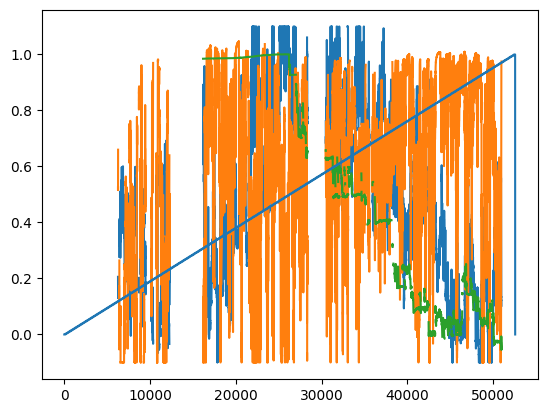

In [13]:
plt.plot(data_test[0])

In [20]:
data_train = np.load('/home/lukovic/data/treenet/outputs_yearly/X.npy')
data_train[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [21]:
data_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(52560, 11), dtype=float32)

In [24]:
X = np.load('/home/lukovic/data/treenet/outputs_yearly/X.npy')
np.isnan(X).sum(), X.shape


(np.int64(0), (52560, 11))

In [25]:
T = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/thermometer_l1/thermometer_l1_series_id_10.ftr')
T

,ts,series,value
0,2012-08-28 00:00:00+01:00,10,15.912641
1,2012-08-28 00:10:00+01:00,10,16.058209
2,2012-08-28 00:20:00+01:00,10,16.145530
3,2012-08-28 00:30:00+01:00,10,16.247044
4,2012-08-28 00:40:00+01:00,10,16.414811
...,...,...,...
416999,2022-09-27 23:20:00+01:00,10,5.126934
417000,2022-09-27 23:30:00+01:00,10,5.071902
417001,2022-09-27 23:40:00+01:00,10,5.019254
417002,2022-09-27 23:50:00+01:00,10,4.990260


In [27]:
H = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1/hygrometer_l1_series_id_8.ftr')
H

,ts,series,value
0,2012-08-24 08:00:00+01:00,8,74.161944
1,2012-08-24 08:10:00+01:00,8,76.349697
2,2012-08-24 08:20:00+01:00,8,77.110977
3,2012-08-24 08:30:00+01:00,8,74.506894
4,2012-08-24 08:40:00+01:00,8,71.197269
...,...,...,...
417527,2022-09-27 23:20:00+01:00,8,89.340061
417528,2022-09-27 23:30:00+01:00,8,89.521448
417529,2022-09-27 23:40:00+01:00,8,89.673319
417530,2022-09-27 23:50:00+01:00,8,89.810547


In [28]:
D = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_l2/dendrometer_l2_series_id_18.ftr')
D

,ts,series,value,max,twd,gro_yr,gro_start,gro_end,frost,flags
0,2019-04-23 09:10:00+01:00,18,12590.962199,12590.962199,0.000000,0,NaN,NaN,False,None
1,2019-04-23 09:20:00+01:00,18,12590.910276,12590.962199,0.051923,0,NaN,NaN,False,None
2,2019-04-23 09:30:00+01:00,18,12590.736787,12590.962199,0.225413,0,NaN,NaN,False,None
3,2019-04-23 09:40:00+01:00,18,12590.582252,12590.962199,0.379948,0,NaN,NaN,False,None
4,2019-04-23 09:50:00+01:00,18,12590.467293,12590.962199,0.494906,0,NaN,NaN,False,None
...,...,...,...,...,...,...,...,...,...,...
308251,2025-06-21 23:10:00+01:00,18,5950.911967,5950.911967,0.000000,1496,NaN,NaN,False,None
308252,2025-06-21 23:20:00+01:00,18,5951.576464,5951.576464,0.000000,1497,NaN,NaN,False,None
308253,2025-06-21 23:30:00+01:00,18,5952.149451,5952.149451,0.000000,1498,NaN,NaN,False,None
308254,2025-06-21 23:40:00+01:00,18,5952.784959,5952.784959,0.000000,1498,NaN,NaN,False,None


In [3]:
pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_l2/dendrometer_lm_series_id_18.ftr')


FileNotFoundError: [Errno 2] No such file or directory: '/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_l2/dendrometer_lm_series_id_18.ftr'

In [4]:
dendro18l2 = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_18.ftr')
dendro18l2[0:20]

,ts,series,value,max,twd,gro_yr,gro_start,gro_end,frost,flags,temp,rh,swp,total_precip,rad,vpd,vpd_bo
0,2014-12-31 00:10:00+01:00,18,25.034640,25.034640,0.000000,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-31 00:20:00+01:00,18,25.034640,25.034640,0.000000,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-31 00:30:00+01:00,18,25.034640,25.034640,0.000000,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-31 00:40:00+01:00,18,24.788506,25.034640,0.246134,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-31 00:50:00+01:00,18,24.933353,25.034640,0.101287,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2014-12-31 01:00:00+01:00,18,25.089121,25.089121,0.000000,0.0,NaN,NaN,True,None,-0.414358,94.467537,-10.599988,0.131955,0.612661,0.032935,NaN
6,2014-12-31 01:10:00+01:00,18,24.832675,25.089121,0.256446,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2014-12-31 01:20:00+01:00,18,25.282945,25.282945,0.000000,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2014-12-31 01:30:00+01:00,18,24.945472,25.282945,0.337473,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2014-12-31 01:40:00+01:00,18,24.975390,25.282945,0.307555,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
dendro18lm = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_18.ftr')[['ts','value','temp','rh']]
dendro18lm[dendro18lm.ts.dt.year == 2024][0:20]

,ts,value,temp,rh
376478,2024-01-01 00:10:00+01:00,25226.185791,0.113075,NaN
376479,2024-01-01 00:20:00+01:00,25226.180287,0.134059,NaN
376480,2024-01-01 00:30:00+01:00,25226.189626,0.112735,NaN
376481,2024-01-01 00:40:00+01:00,25226.191485,0.092641,NaN
376482,2024-01-01 00:50:00+01:00,25226.197530,0.057048,NaN
376483,2024-01-01 01:00:00+01:00,25226.190592,-0.082288,NaN
376484,2024-01-01 01:10:00+01:00,25226.197170,-0.176399,NaN
376485,2024-01-01 01:20:00+01:00,25226.200669,-0.078853,NaN
376486,2024-01-01 01:30:00+01:00,25226.243675,-0.006083,NaN
376487,2024-01-01 01:40:00+01:00,25226.257171,0.054256,NaN


In [75]:
temp18lm = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_18.ftr')[['ts','value','temp','rh']].dropna()
temp18lm[temp18lm.ts.dt.year < 2023]

,ts,value,temp,rh
5,2014-12-31 01:00:00+01:00,25.089121,-0.414358,94.467537
11,2014-12-31 02:00:00+01:00,24.790419,-0.381082,94.487883
17,2014-12-31 03:00:00+01:00,25.034640,-0.470638,94.434756
23,2014-12-31 04:00:00+01:00,25.034640,-0.673768,94.302666
29,2014-12-31 05:00:00+01:00,25.085919,-0.912375,94.147555
...,...,...,...,...
324032,2022-12-31 19:00:00+01:00,22226.842005,11.374349,57.838545
324038,2022-12-31 20:00:00+01:00,22226.846272,10.927619,58.434415
324044,2022-12-31 21:00:00+01:00,22227.099208,10.904703,57.478638
324050,2022-12-31 22:00:00+01:00,22227.205815,10.781701,58.335953


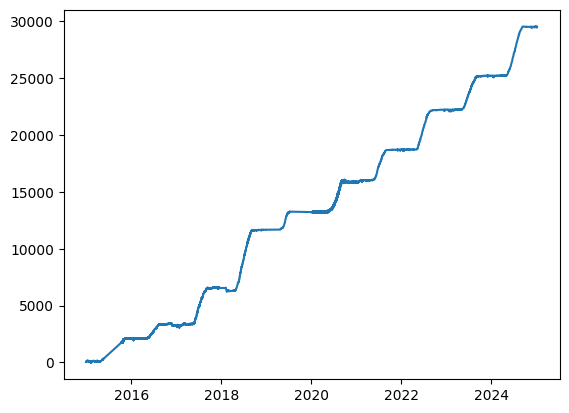

In [50]:
plt.plot(dendro18l2['ts'], dendro18l2['value'])

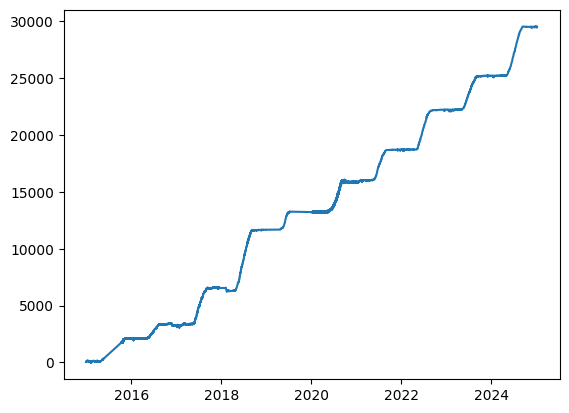

In [53]:
plt.plot(dendro18lm['ts'], dendro18lm['value'])

In [1]:

from build_normalized_dataset_treenet_utc import read_lm_hourly_frame_utc

lm = read_lm_hourly_frame_utc(
    18,
    "/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm",
    "Europe/Zurich"
)

print(lm['2014-12-31 00:00:00+00:00':'2014-12-31 05:00:00+00:00'])
print("NaN ratios:", lm.isna().mean().to_dict())


                                stem   local_T   local_RH
2014-12-31 00:00:00+00:00  25.089121 -0.414358  94.467537
2014-12-31 01:00:00+00:00  24.790419 -0.381082  94.487883
2014-12-31 02:00:00+00:00  25.034640 -0.470638  94.434756
2014-12-31 03:00:00+00:00  25.034640 -0.673768  94.302666
2014-12-31 04:00:00+00:00  25.085919 -0.912375  94.147555
2014-12-31 05:00:00+00:00  25.281550 -0.951480  94.104188
NaN ratios: {'stem': 0.1843783451385884, 'local_T': 0.18482246566606692, 'local_RH': 0.3581091853235247}


In [4]:
temp18lm = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_18.ftr')[['ts','value','temp','rh']]
temp18lm[temp18lm.ts.dt.year == 2019]

,ts,value,temp,rh
163727,2019-04-23 10:00:00+01:00,11671.01391,15.765701,58.652069
163728,2019-04-23 10:10:00+01:00,11670.92093,NaN,NaN
163729,2019-04-23 10:20:00+01:00,11670.90185,NaN,NaN
163730,2019-04-23 10:30:00+01:00,11670.60621,NaN,NaN
163731,2019-04-23 10:40:00+01:00,11670.56330,NaN,NaN
...,...,...,...,...
174096,2019-07-07 12:30:00+01:00,13265.46677,NaN,NaN
174097,2019-07-07 12:40:00+01:00,13263.18987,NaN,NaN
174098,2019-07-07 12:50:00+01:00,13262.18136,NaN,NaN
174099,2019-07-07 13:00:00+01:00,13262.05500,21.659243,72.013897


In [17]:

import pandas as pd
df = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_18.ftr')
df = df[df.ts.dt.year == 2023]
df[0:20]

,ts,series,value,max,twd,gro_yr,gro_start,gro_end,frost,flags,temp,rh,swp,total_precip,rad,vpd,vpd_bo
324062,2023-01-01 00:00:00+01:00,18,22227.308358,22243.423169,16.114811,0.0,NaN,NaN,False,None,10.596157,59.097004,-9.6,NaN,0.0,0.524509,NaN
324063,2023-01-01 00:10:00+01:00,18,22227.303495,22243.423169,16.119674,0.0,NaN,NaN,False,None,10.132780,NaN,NaN,NaN,NaN,NaN,NaN
324064,2023-01-01 00:20:00+01:00,18,22227.297304,22243.423169,16.125865,0.0,NaN,NaN,False,None,10.154369,NaN,NaN,NaN,NaN,NaN,NaN
324065,2023-01-01 00:30:00+01:00,18,22227.308723,22243.423169,16.114446,0.0,NaN,NaN,False,None,9.985288,NaN,NaN,NaN,NaN,NaN,NaN
324066,2023-01-01 00:40:00+01:00,18,22227.311107,22243.423169,16.112062,0.0,NaN,NaN,False,None,10.184730,NaN,NaN,NaN,NaN,NaN,NaN
324067,2023-01-01 00:50:00+01:00,18,22227.313486,22243.423169,16.109683,0.0,NaN,NaN,False,None,10.456364,NaN,NaN,NaN,NaN,NaN,NaN
324068,2023-01-01 01:00:00+01:00,18,22227.315395,22243.423169,16.107774,0.0,NaN,NaN,False,None,10.181015,60.505424,-9.6,NaN,0.0,0.492607,NaN
324069,2023-01-01 01:10:00+01:00,18,22227.309344,22243.423169,16.113825,0.0,NaN,NaN,False,None,10.526202,NaN,NaN,NaN,NaN,NaN,NaN
324070,2023-01-01 01:20:00+01:00,18,22227.325524,22243.423169,16.097645,0.0,NaN,NaN,False,None,10.442934,NaN,NaN,NaN,NaN,NaN,NaN
324071,2023-01-01 01:30:00+01:00,18,22227.332580,22243.423169,16.090589,0.0,NaN,NaN,False,None,10.408803,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_18.ftr')
df = df[df.ts.dt.year == 2024]
df[['ts', 'value', 'temp', 'rh']].dropna()

,ts,value,temp,rh


In [8]:
df = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1/hygrometer_l1_series_id_1720.ftr'); 
#df = df[df.ts.dt.year == 2019]
df

,ts,series,value
0,2024-04-17 00:10:00+01:00,1720,82.068987
1,2024-04-17 00:20:00+01:00,1720,81.850020
2,2024-04-17 00:30:00+01:00,1720,80.999484
3,2024-04-17 00:40:00+01:00,1720,80.347261
4,2024-04-17 00:50:00+01:00,1720,79.695308
...,...,...,...
61895,2025-06-21 23:10:00+01:00,1720,69.151606
61896,2025-06-21 23:20:00+01:00,1720,68.042247
61897,2025-06-21 23:30:00+01:00,1720,67.540769
61898,2025-06-21 23:40:00+01:00,1720,68.614372


In [28]:
df = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/thermometer_l1/thermometer_l1_series_id_10.ftr')
df = df[df.ts.dt.year == 2019]
df[['ts', 'value']].dropna()

,ts,value
247065,2019-02-13 12:50:00+01:00,4.259809
247066,2019-02-13 13:00:00+01:00,4.138151
247067,2019-02-13 13:10:00+01:00,3.622524
247068,2019-02-13 13:20:00+01:00,3.312932
247069,2019-02-13 13:30:00+01:00,3.252508
...,...,...
279573,2019-12-20 22:10:00+01:00,2.306286
279574,2019-12-20 22:20:00+01:00,2.168737
279575,2019-12-20 22:30:00+01:00,2.049009
279576,2019-12-20 22:40:00+01:00,2.097648


In [30]:
df = pd.read_csv('/storage/lukovic/Data/FORWARDS/treenet/meteo_data/site_3.csv'); print(df.dtypes); print(df.head(5))

ts         object
ff        float64
gh        float64
pr        float64
tas       float64
tasmax    float64
tasmin    float64
rh        float64
vpd       float64
dtype: object
           ts   ff         gh         pr  tas  tasmax  tasmin          rh  \
0  1981-01-01  2.2  17.300001   8.900024 -3.7     1.2    -8.7  100.000000   
1  1981-01-02  1.7  19.600000   6.599976  1.7     3.5    -3.1   78.694595   
2  1981-01-03  1.8  17.600000  34.000000  4.8     7.6    -0.6   76.928750   
3  1981-01-04  1.5  12.700000  26.000000  2.7     5.6    -1.6   84.795520   
4  1981-01-05  2.2  29.900000   4.200073 -4.6    -3.9    -5.5   98.500374   

        vpd  
0  0.000000  
1  0.147763  
2  0.199228  
3  0.113246  
4  0.006545  


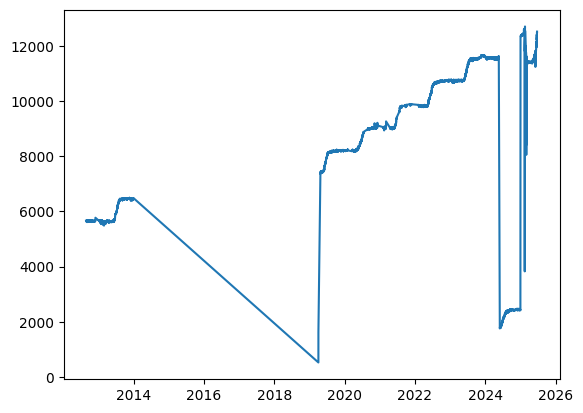

In [ ]:
df = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_l2/dendrometer_l2_series_id_20.ftr')

plt.plot(df['ts'], df['value'])

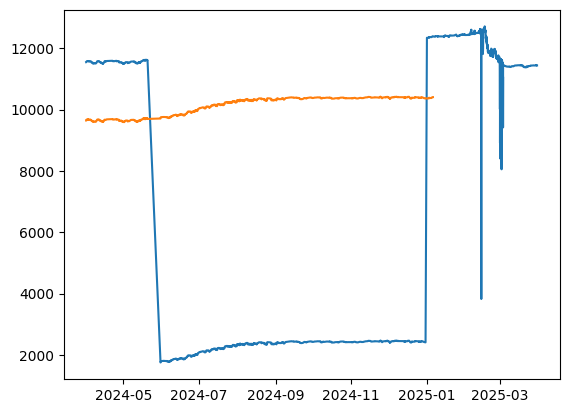

In [176]:
start_date = '2024-04-01 00:00:00+01:00'
end_date = '2025-03-30 23:50:00+01:00'
mask = (df['ts'] >= start_date) & (df['ts'] <= end_date)

plt.plot(df[mask]['ts'], df[mask]['value'])

start_date = '2024-04-01 00:00:00+01:00'
end_date = '2025-03-30 23:50:00+01:00'
mask = (df2['ts'] >= start_date) & (df2['ts'] <= end_date)

plt.plot(df2[mask]['ts'], df2[mask]['value'])


In [ ]:
start_date = '2024-04-01 00:00:00+01:00'
end_date = '2025-03-30 23:50:00+01:00'
mask = (df['ts'] >= start_date) & (df['ts'] <= end_date)

plt.plot(df[mask]['ts'], df[mask]['value'])

In [172]:
df2 = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_20.ftr')
df2

,ts,series,value,max,twd,gro_yr,gro_start,gro_end,frost,flags,temp,rh,swp,total_precip,rad,vpd,vpd_bo
0,2012-08-29 06:50:00+01:00,20,1040.260000,1040.260000,0.000000,0.0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-08-29 07:00:00+01:00,20,1040.109654,1040.260000,0.150346,0.0,NaN,NaN,False,None,16.667784,68.693394,NaN,0.0,59.803826,0.595962,NaN
2,2012-08-29 07:10:00+01:00,20,1040.331392,1040.331392,0.000000,0.0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-08-29 07:20:00+01:00,20,1039.871805,1040.331392,0.459587,0.0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-08-29 07:30:00+01:00,20,1039.877047,1040.331392,0.454345,0.0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504724,2025-01-05 22:10:00+01:00,20,10405.396596,10421.537731,16.141135,NaN,NaN,NaN,False,None,6.909383,NaN,NaN,NaN,NaN,NaN,NaN
504725,2025-01-05 22:20:00+01:00,20,10405.357433,10421.537731,16.180298,NaN,NaN,NaN,False,None,7.604317,NaN,NaN,NaN,NaN,NaN,NaN
504726,2025-01-05 22:30:00+01:00,20,10405.326508,10421.537731,16.211223,NaN,NaN,NaN,False,None,6.637254,NaN,NaN,NaN,NaN,NaN,NaN
504727,2025-01-05 22:40:00+01:00,20,10405.337597,10421.537731,16.200134,NaN,NaN,NaN,False,None,6.481037,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
np.load('/home/lukovic/data/treenet/outputs_yearly/y_train_30d.npy')

array([], shape=(0, 0, 3), dtype=float32)

In [39]:

import pickle

base = '/home/lukovic/data/treenet/outputs_30d/processed/model_data'

with open(f'{base}/train_input_segments_numpy.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open(f'{base}/train_output_segments_numpy.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open(f'{base}/test_input_segments_numpy.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open(f'{base}/test_output_segments_numpy.pkl', 'rb') as f:
    y_test = pickle.load(f)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
# Expected: (24, 4320, 11) (24, 720, 3)  for both TRAIN/TEST in your latest run


(24, 4320, 11) (24, 720, 3)
(24, 4320, 11) (24, 720, 3)


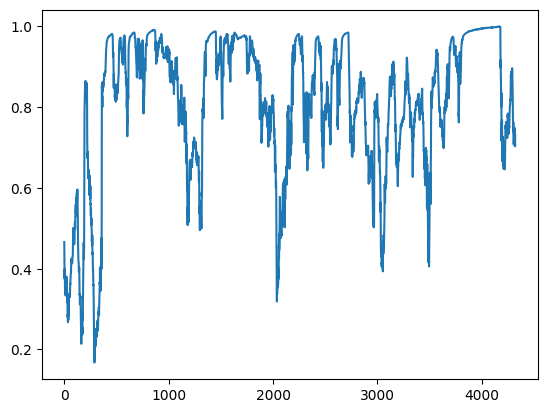

In [43]:
plt.plot(X_train[0][:,1])

In [44]:

import pickle

base = '/home/lukovic/data/treenet/outputs_30d/processed/model_data'

train_combo_ids = pickle.load(open(f'{base}/model_train_data_combination_ids.pkl', 'rb'))
train_seg_ids   = pickle.load(open(f'{base}/train_segment_ids.pkl', 'rb'))

print('Total combos discovered:', len(train_combo_ids))
print('Combos with segments:', sorted(train_seg_ids.keys())[:10], '...')
print('Segments per combo (first few):', {k: len(train_seg_ids[k]) for k in list(train_seg_ids.keys())[:5]})

# You can also print an example combo's IDs row:
example_combo = next(iter(train_seg_ids.keys()))
print('Example combo IDs row:', train_combo_ids[example_combo])


Total combos discovered: 28
Combos with segments: [21, 22, 23, 24, 26, 27] ...
Segments per combo (first few): {21: 1, 22: 1, 23: 8, 24: 7, 26: 6}
Example combo IDs row: site ID            3
thermometer ID    10
hygrometer ID      8
dendrometer ID    18
Name: 0, dtype: int64


In [48]:
train_combo_ids[22]

site ID            3
thermometer ID    10
hygrometer ID      8
dendrometer ID    19
Name: 0, dtype: int64

In [54]:
train_seg_ids[21]

[[21,
  0,
  site ID            3
  thermometer ID    10
  hygrometer ID      8
  dendrometer ID    18
  Name: 0, dtype: int64,
  {'temp_treenet': -4.3640271484375,
   'rh_treenet': 18.6760050455729,
   'stem': -85519.204389,
   'tas': -7.2000003,
   'tasmax': -5.7000003,
   'tasmin': -9.400001,
   'rh': 27.956799,
   'vpd': 0.005614441,
   'gh': 7.1,
   'pr': 0.0,
   'doy': 1.0},
  {'temp_treenet': 37.1912870788574,
   'rh_treenet': 75.22303263346359,
   'stem': 99615.09401900001,
   'tas': 32.5000013,
   'tasmax': 35.5000013,
   'tasmin': 30.800000999999998,
   'rh': 71.351051,
   'vpd': 1.688125659,
   'gh': 374.79999999999995,
   'pr': 60.30005,
   'doy': 365.0},
  {'stem': 11666.271365, 'local_T': -3.235551, 'local_RH': 32.053354},
  {'stem': 1605.979601666666, 'local_T': 35.599111, 'local_RH': 67.946646},
  {'window_start_utc': '2019-04-23T08:10:00+00:00',
   'window_end_utc': '2019-05-23T08:10:00+00:00'},
  {'input_channels': ['temp_treenet',
    'rh_treenet',
    'stem',
    't

In [55]:
pd.read_csv('/storage/lukovic/Data/FORWARDS/treenet/server_data/meteo_data/site_99.csv')

,ts,ff,gh,pr,tas,tasmax,tasmin,rh,vpd
0,1981-01-01,4.4,68.200005,0.300049,-0.4,5.0,-9.2,75.475464,0.146161
1,1981-01-02,5.2,66.700005,2.200073,0.1,1.8,-1.6,83.868320,0.099702
2,1981-01-03,4.9,58.800000,23.000000,2.4,5.5,-0.7,80.550644,0.141818
3,1981-01-04,5.8,15.700000,17.099976,2.2,3.9,-1.2,89.147934,0.078010
4,1981-01-05,6.8,75.500000,1.500000,-1.8,-0.3,-2.6,71.857390,0.151366
...,...,...,...,...,...,...,...,...,...
16066,2024-12-27,1.1,58.500000,0.000000,-1.6,2.1,-3.6,79.360344,0.112659
16067,2024-12-28,1.0,56.800000,0.000000,-1.4,2.5,-3.6,75.869810,0.133663
16068,2024-12-29,1.0,55.700000,0.000000,-1.8,0.3,-4.0,78.731120,0.114395
16069,2024-12-30,1.1,57.800000,0.000000,-1.6,2.8,-3.5,74.690550,0.138148


In [67]:
data = pd.read_pickle('/storage/lukovic/Data/FORWARDS/treenet/server_data/processed/model_data/train_segment_ids.pkl')
data

{0: [0,
  0,
  site ID            3
  thermometer ID     9
  hygrometer ID      7
  dendrometer ID    18
  Name: 0, dtype: int64,
  {'temp_treenet': np.float64(2.28502581317871),
   'rh_treenet': np.float64(33.3146486610208),
   'stem': np.float64(18271.836978),
   'tas': np.float64(2.9),
   'tasmax': np.float64(3.9),
   'tasmin': np.float64(1.6),
   'rh': np.float64(43.565376),
   'vpd': np.float64(0.040651124),
   'gh': np.float64(20.7),
   'pr': np.float64(0.0),
   'doy': 1.0},
  {'temp_treenet': np.float64(20.31045229413709),
   'rh_treenet': np.float64(66.6853513389792),
   'stem': np.float64(41.65289000000121),
   'tas': np.float64(15.400001000000001),
   'tasmax': np.float64(18.700000000000003),
   'tasmin': np.float64(13.6),
   'rh': np.float64(53.135659000000004),
   'vpd': np.float64(1.1502485759999999),
   'gh': np.float64(130.70001000000002),
   'pr': np.float64(12.800049),
   'doy': 365.0},
  {'temp': np.float64(2.499072),
   'rh': np.float64(34.693138),
   'value': np.flo

In [150]:
counter = 0
for el, value in data.items():
    if int(value[2]['site ID']) == 3:
        print(value[0], value[1], value[2]['thermometer ID'], value[2]['hygrometer ID'], value[2]['dendrometer ID'])
        counter += 1
print(counter)

0 0 9 7 18
0 1 9 7 18
0 2 9 7 18
0 3 9 7 18
0 4 9 7 18
1 0 9 7 19
1 1 9 7 19
1 2 9 7 19
1 3 9 7 19
1 4 9 7 19
1 5 9 7 19
1 6 9 7 19
1 7 9 7 19
2 0 9 7 20
2 1 9 7 20
2 2 9 7 20
2 3 9 7 20
2 4 9 7 20
2 5 9 7 20
2 6 9 7 20
3 0 9 7 21
3 1 9 7 21
3 2 9 7 21
4 0 9 7 22
4 1 9 7 22
4 2 9 7 22
4 3 9 7 22
4 4 9 7 22
4 5 9 7 22
5 0 9 7 23
5 1 9 7 23
5 2 9 7 23
5 3 9 7 23
5 4 9 7 23
5 5 9 7 23
5 6 9 7 23
5 7 9 7 23
21 0 10 8 18
21 1 10 8 18
21 2 10 8 18
21 3 10 8 18
21 4 10 8 18
21 5 10 8 18
21 6 10 8 18
21 7 10 8 18
21 8 10 8 18
21 9 10 8 18
21 10 10 8 18
21 11 10 8 18
21 12 10 8 18
21 13 10 8 18
21 14 10 8 18
21 15 10 8 18
21 16 10 8 18
21 17 10 8 18
21 18 10 8 18
21 19 10 8 18
22 0 10 8 19
22 1 10 8 19
22 2 10 8 19
22 3 10 8 19
22 4 10 8 19
22 5 10 8 19
22 6 10 8 19
22 7 10 8 19
22 8 10 8 19
22 9 10 8 19
22 10 10 8 19
22 11 10 8 19
22 12 10 8 19
22 13 10 8 19
22 14 10 8 19
22 15 10 8 19
22 16 10 8 19
22 17 10 8 19
23 0 10 8 20
23 1 10 8 20
23 2 10 8 20
23 3 10 8 20
23 4 10 8 20
23 5 10 8 20
23 

In [66]:
el = data[0]
print(el[2]['site ID'])

3


In [59]:
for i in range(0,100):
    print(data[i][2])

site ID            3
thermometer ID     9
hygrometer ID      7
dendrometer ID    18
Name: 0, dtype: int64
site ID            3
thermometer ID     9
hygrometer ID      7
dendrometer ID    18
Name: 0, dtype: int64
site ID            3
thermometer ID     9
hygrometer ID      7
dendrometer ID    18
Name: 0, dtype: int64
site ID            3
thermometer ID     9
hygrometer ID      7
dendrometer ID    18
Name: 0, dtype: int64
site ID            3
thermometer ID     9
hygrometer ID      7
dendrometer ID    18
Name: 0, dtype: int64
site ID            3
thermometer ID     9
hygrometer ID      7
dendrometer ID    19
Name: 0, dtype: int64
site ID            3
thermometer ID     9
hygrometer ID      7
dendrometer ID    19
Name: 0, dtype: int64
site ID            3
thermometer ID     9
hygrometer ID      7
dendrometer ID    19
Name: 0, dtype: int64
site ID            3
thermometer ID     9
hygrometer ID      7
dendrometer ID    19
Name: 0, dtype: int64
site ID            3
thermometer ID     9
hygr

In [ ]:
df_out = pd.read_pickle('/storage/lukovic/Data/FORWARDS/treenet/server_data/processed/model_data/train_output_segments_pandas.pkl')

In [36]:
dfout[0][3][0]

,ts,temp,rh,value
315932,2022-11-05 13:00:00+01:00,0.384839,1.000000,0.427812
315938,2022-11-05 14:00:00+01:00,0.380202,1.000000,0.428458
315944,2022-11-05 15:00:00+01:00,0.380353,1.000000,0.428082
315950,2022-11-05 16:00:00+01:00,0.348135,1.000000,0.429265
315956,2022-11-05 17:00:00+01:00,0.319477,0.989867,0.440830
...,...,...,...,...
320222,2022-12-05 08:00:00+01:00,0.114460,1.000000,0.991240
320228,2022-12-05 09:00:00+01:00,0.110139,1.000000,0.991557
320234,2022-12-05 10:00:00+01:00,0.106238,1.000000,0.991876
320240,2022-12-05 11:00:00+01:00,0.121634,1.000000,0.991454


In [153]:
b = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/processed/model_data/train_input_combination_24.ftr')

In [95]:
b

,ts,temp_treenet,rh_treenet,stem,tas,tasmax,tasmin,rh,vpd,gh,pr,doy
0,2012-08-24 08:00:00+01:00,NaN,74.161944,NaN,16.6,19.800001,14.6,85.17301,0.281032,121.8,19.400024,237
1,2012-08-24 08:10:00+01:00,NaN,76.349697,NaN,16.6,19.800001,14.6,85.17301,0.281032,121.8,19.400024,237
2,2012-08-24 08:20:00+01:00,NaN,77.110977,NaN,16.6,19.800001,14.6,85.17301,0.281032,121.8,19.400024,237
3,2012-08-24 08:30:00+01:00,NaN,74.506894,NaN,16.6,19.800001,14.6,85.17301,0.281032,121.8,19.400024,237
4,2012-08-24 08:40:00+01:00,NaN,71.197269,NaN,16.6,19.800001,14.6,85.17301,0.281032,121.8,19.400024,237
...,...,...,...,...,...,...,...,...,...,...,...,...
561450,2025-06-21 23:10:00+01:00,NaN,NaN,13817.640731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172
561451,2025-06-21 23:20:00+01:00,NaN,NaN,13818.999836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172
561452,2025-06-21 23:30:00+01:00,NaN,NaN,13820.321116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172
561453,2025-06-21 23:40:00+01:00,NaN,NaN,13821.826912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172


In [160]:
start_date = '2016-10-01 00:00:00+01:00'
end_date = '2016-11-30 23:50:00+01:00'
mask = (b['ts'] >= start_date) & (b['ts'] <= end_date)
b[mask]

,ts,temp_treenet,rh_treenet,stem,tas,tasmax,tasmin,rh,vpd,gh,pr,doy
148650,2016-10-01 00:00:00+01:00,13.117616,66.110771,NaN,12.3,16.0,9.400001,79.188190,0.298731,118.300000,1.200073,275
148651,2016-10-01 00:10:00+01:00,12.768795,67.463299,NaN,12.3,16.0,9.400001,79.188190,0.298731,118.300000,1.200073,275
148652,2016-10-01 00:20:00+01:00,12.669075,67.362951,NaN,12.3,16.0,9.400001,79.188190,0.298731,118.300000,1.200073,275
148653,2016-10-01 00:30:00+01:00,12.684217,67.269831,NaN,12.3,16.0,9.400001,79.188190,0.298731,118.300000,1.200073,275
148654,2016-10-01 00:40:00+01:00,12.892965,66.089759,NaN,12.3,16.0,9.400001,79.188190,0.298731,118.300000,1.200073,275
...,...,...,...,...,...,...,...,...,...,...,...,...
157392,2016-11-30 23:10:00+01:00,1.204619,82.814810,NaN,-0.1,3.1,-3.100000,82.608215,0.105929,79.700005,0.000000,335
157393,2016-11-30 23:20:00+01:00,1.111191,83.350391,NaN,-0.1,3.1,-3.100000,82.608215,0.105929,79.700005,0.000000,335
157394,2016-11-30 23:30:00+01:00,1.480481,81.900516,NaN,-0.1,3.1,-3.100000,82.608215,0.105929,79.700005,0.000000,335
157395,2016-11-30 23:40:00+01:00,1.679235,80.895819,NaN,-0.1,3.1,-3.100000,82.608215,0.105929,79.700005,0.000000,335


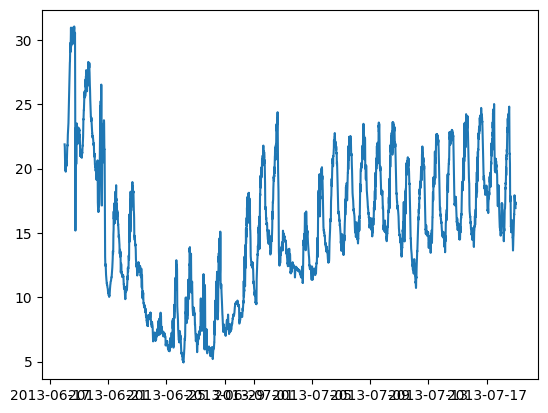

In [138]:
plt.plot(c[mask].ts, c[mask].temp_treenet)

In [161]:
import datetime
import pandas as pd

length_in_days = 30
stride = 10

segment_length = length_in_days * 24  # Note: converts the segment length from days to time-samps
stride_length = stride * 24

data_path = "/storage/lukovic/Data/FORWARDS/treenet/server_data/"
input_signal = pd.read_feather(data_path + "processed/model_data/train_input_combination_24.ftr").dropna()
output_signal = pd.read_feather(data_path + "processed/model_data/train_output_combination_24.ftr").dropna()

max_length = len(output_signal)
input_temp = []
output_temp = []
idx_change = 1
idx = 0

input_times = pd.DatetimeIndex(input_signal['ts'])
output_times = pd.DatetimeIndex(output_signal['ts'])

while (idx + segment_length) < max_length:
    start_time = output_signal.iloc[idx]['ts']
    stop_time = output_signal.iloc[segment_length + idx]['ts']
    if stop_time - start_time == datetime.timedelta(days=length_in_days):
        # Determine if the start and stop times of the output segment exist in the input signal
        if (start_time in input_times) and (stop_time in input_times):
            index_a = input_signal[input_signal['ts']==start_time].index.values[0] # start of input segment
            index_b = input_signal[input_signal['ts']==stop_time].index.values[0] # stop of input segment
            if input_signal.index.get_loc(index_b)-input_signal.index.get_loc(index_a) == segment_length*6: # check whether the segment is of the right size, otherwise there are holes in it.
                input_temp.append(input_signal.loc[index_a:index_b-1])
                output_temp.append(output_signal.iloc[idx:idx + segment_length])
                idx_change = stride_length
                #display(input_signal.loc[index_a:index_b-1])
                #display(output_signal.iloc[idx:idx + segment_length])
            else:
                idx_change = 1
        else: idx_change = 1
    else: idx_change = 1
    idx += idx_change

print(len(input_temp), len(output_temp))

62 62


In [149]:
len(output_temp)

61

In [148]:
len(input_temp)

61

In [ ]:
input_temp[]